In [ ]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
df_us_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')

In [5]:
df_us_jobs = df[df['job_country'] == 'United States'].copy()

In [6]:
df_us_jobs['job_posted_month'] = df_us_jobs['job_posted_date'].dt.strftime('%B')

In [7]:
df_us_pivot = df_us_jobs.pivot_table(
    index='job_posted_month', 
    columns='job_title_short',
    aggfunc='size'
)

In [8]:
df_us_pivot.reset_index(inplace=True)

In [9]:
df_us_pivot['month_no'] = pd.to_datetime(df_us_pivot['job_posted_month'], format='%B').dt.month

In [10]:
df_us_pivot.sort_values('month_no', inplace=True)

In [11]:
df_us_pivot.set_index('job_posted_month', inplace=True)

In [12]:
df_us_pivot.drop(columns=['month_no'], inplace=True)

In [13]:
top_3 = df_us_jobs['job_title_short'].value_counts(ascending=False).head(3)

In [17]:
top_3 = top_3.index.tolist()

In [22]:
df_us_merged = df_us_pivot[top_3].merge(df_us_software_pivot, on='job_posted_month')

In [30]:
top_5 = (
    df_us_merged
    .sum()
    .sort_values(ascending=False)
    .head()
    .index # Get the index (job_title_short) of the top 5
    .tolist()
)

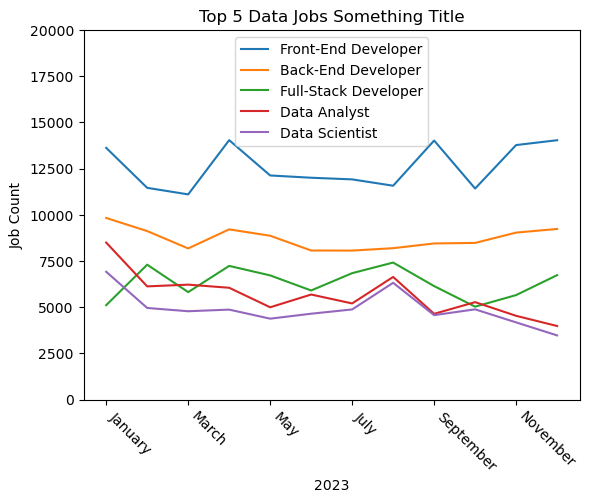

In [37]:
df_us_merged[top_5].plot(kind='line')

plt.title('Top 5 Data Jobs Something Title')
plt.ylabel('Job Count')
plt.ylim(0, 20000)
plt.xlabel('2023')
plt.xticks(rotation=-45, ha='left')

plt.show()